<a href="https://colab.research.google.com/github/momopom-12/call-center-demand-forecast/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Call Center Demand Analysis

## Objective

Analyze historical call center demand and estimate workforce requirements to support operational planning decisions.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("call_center_data.csv")
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,calls_received,aht_seconds,sla_target,available_agents,shrinkage,is_weekend,is_peak_day
0,2025-01-01,1200,420,0.8,35,0.25,0,0
1,2025-01-02,1350,415,0.8,36,0.25,0,0
2,2025-01-03,1420,430,0.8,36,0.25,0,0
3,2025-01-04,1100,440,0.8,30,0.25,1,0
4,2025-01-05,1050,445,0.8,28,0.25,1,0


## Demand Analysis

We start by analyzing call volume over time to identify trends and potential peaks.

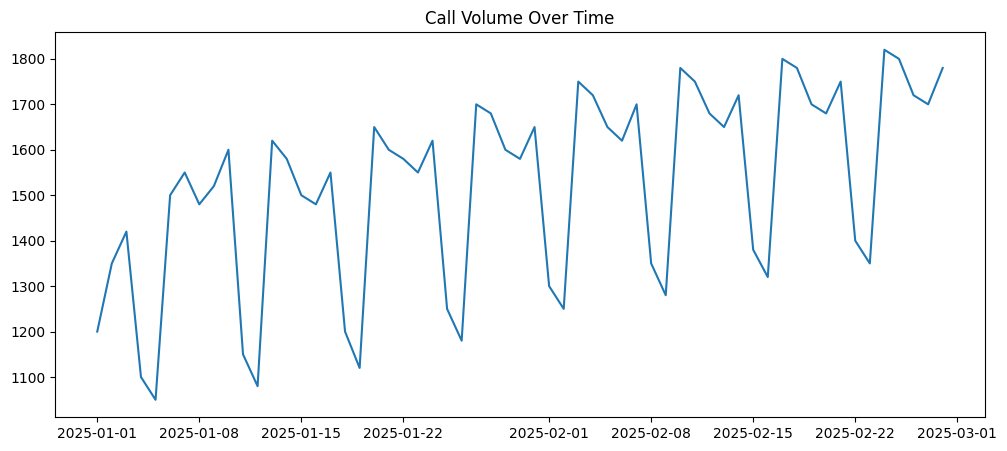

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['calls_received'])
plt.title("Call Volume Over Time")
plt.show()

## Forecasting

A simple moving average is used to estimate short-term demand trends.

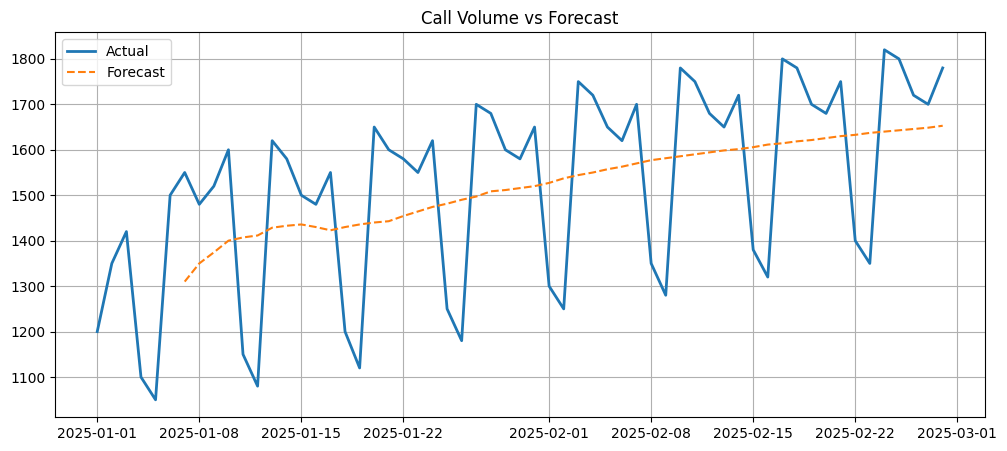

In [12]:
df['forecast'] = df['calls_received'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['calls_received'], label='Actual', linewidth=2)
plt.plot(df['date'], df['forecast'], label='Forecast', linestyle='--')
plt.title("Call Volume vs Forecast")
plt.legend()
plt.grid()
plt.show()

## Workforce Estimation

We estimate the number of agents required based on call volume, AHT and available working time.

In [13]:
df['required_agents'] = (
    df['calls_received'] * df['aht_seconds']
) / (6 * 3600 * (1 - df['shrinkage']))

df[['date', 'required_agents']].head()

,date,required_agents
0,2025-01-01,31.111111
1,2025-01-02,34.583333
2,2025-01-03,37.691358
3,2025-01-04,29.876543
4,2025-01-05,28.842593


## Key Insights

- Demand is significantly higher during weekdays compared to weekends  
- Peak days require careful workforce planning to avoid SLA breaches  
- Forecasting helps anticipate short-term demand fluctuations  
- Workforce requirements vary considerably depending on demand and AHT  

## Business Impact

This type of analysis can support better staffing decisions, reduce operational costs and improve service levels in high-demand environments.